# Figure 3 — Final model performance and interpretability panel

This notebook generates the manuscript-ready Figure 3 panel for the final selected predictive model.

The figure includes:

- **A** ROC curves for the selected LDA pipeline across dataset variants.
- **B** Precision–Recall curves under class imbalance.
- **C** Normalized confusion matrix and threshold-dependent clinical metrics.
- **D** SHAP summary / beeswarm-style global contribution plot.
- **E** Mean absolute SHAP values with effect direction.
- **F** Cross-validated permutation importance.

The implementation retrains the final selected model using the project datasets and avoids relying on toy values.


In [9]:

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple, Sequence, Optional
import warnings
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from scipy import stats

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")


## 1. Configuration

In [10]:

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
def find_project_root(start: Optional[Path] = None) -> Path:
    """
    Find project root by searching upward for the expected data directory.
    This makes the notebook portable whether it is run from the repo root,
    notebooks/, or a copied working directory.
    """
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for c in candidates:
        if (c / "data" / "processed_variants").exists():
            return c

    # Fallback used when running from this exported sandbox notebook.
    fallback = Path("/mnt/data/hypercholesterolemia_classifiers_extracted/hypercholesterolemia_classifiers")
    if fallback.exists():
        return fallback

    raise FileNotFoundError("Could not locate project root containing data/processed_variants.")

PROJECT_ROOT = find_project_root("../../")

DATA_DIR = PROJECT_ROOT / "data" / "processed_variants"
FIG_DIR = PROJECT_ROOT / "results" / "figures" / "paper_panels"
STATS_DIR = PROJECT_ROOT / "results" / "tables" / "paper_panels"

FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

STRICT_CSV = DATA_DIR / "hcs_strict_complete_case_20260129_114259.csv"
IMPUTED_CSV = DATA_DIR / "hcs_imputed_exploratory_20260129_114259.csv"

FIGURE_BASENAME = "figure3_final_model_xai_panel"

# ---------------------------------------------------------------------
# Model and evaluation settings
# ---------------------------------------------------------------------
LABEL_COL = "MSPH"

# Operating threshold selected to display the detection vs false-positive trade-off.
# This can be adjusted after clinical discussion.
OPERATING_THRESHOLD = 0.60

N_SPLITS = 5
N_REPEATS = 20
RANDOM_STATE = 42

# Three evaluation scenarios shown in panels A and B.
# STRICT and IMPUTED evaluate the final selected LDA pipeline under repeated CV.
# BEST_OVERALL corresponds to the selected best overall configuration:
# imputed dataset + standard scaling + SMOTE + LDA under repeated stratified holdout.
FINAL_SCENARIO_FOR_CONFUSION = "BEST_OVERALL"

EVALUATION_SCENARIOS = [
    {
        "scenario": "STRICT",
        "display_name": "STRICT",
        "dataset": "STRICT",
        "cv": "repeated_kfold",
        "color_key": "strict",
    },
    {
        "scenario": "IMPUTED",
        "display_name": "IMPUTED",
        "dataset": "IMPUTED",
        "cv": "repeated_kfold",
        "color_key": "imputed",
    },
    {
        "scenario": "BEST_OVERALL",
        "display_name": "Robust selected model",
        "dataset": "IMPUTED",
        "cv": "repeated_stratified_holdout",
        "color_key": "best",
    },
]

# Permutation importance can be expensive; this is still small for this dataset.
PERMUTATION_CV_SPLITS = 5
PERMUTATION_REPEATS = 30

# Main predictors used in the analysis.
PREDICTORS = [
    "Age",
    "Weight",
    "Height",
    "BMI_final",
    "Glycemia",
    "SBP_1T",
    "DBP_1T",
    "TC_1T",
    "TG_1T",
    "HDL_1T",
    "LDL_1T",
]

FEATURE_LABELS: Dict[str, str] = {
    "TC_1T": "TC 1T",
    "LDL_1T": "LDL-C 1T",
    "TG_1T": "TG 1T",
    "HDL_1T": "HDL-C 1T",
    "SBP_1T": "SBP 1T",
    "DBP_1T": "DBP 1T",
    "BMI_final": "BMI",
    "Weight": "Weight",
    "Height": "Height",
    "Glycemia": "Glycemia",
    "Age": "Age",
}

CLASS_LABELS = {0: "MSPH−", 1: "MSPH+"}

# Palette harmonized with Figure 2.
COLORS = {
    "negative": "#1F5A91",
    "positive": "#D97721",
    "strict": "#1F5A91",
    "imputed": "#D97721",
    "best": "#2E7D32",
    "green": "#2E7D32",
    "gray": "#606060",
    "light_gray": "#F2F2F2",
    "dark": "#1A1A1A",
}

SHAP_CMAP = LinearSegmentedColormap.from_list(
    "blue_to_orange",
    ["#1F5A91", "#F7F7F7", "#D97721"],
)

print("Project root:", PROJECT_ROOT)
print("Strict dataset:", STRICT_CSV.exists(), STRICT_CSV)
print("Imputed dataset:", IMPUTED_CSV.exists(), IMPUTED_CSV)


Project root: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers
Strict dataset: True /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/data/processed_variants/hcs_strict_complete_case_20260129_114259.csv
Imputed dataset: True /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/data/processed_variants/hcs_imputed_exploratory_20260129_114259.csv


## 2. Load datasets

In [11]:

# ---------------------------------------------------------------------
# Load datasets
# ---------------------------------------------------------------------
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    missing = [c for c in PREDICTORS + [LABEL_COL] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {path.name}: {missing}")
    return df.copy()

df_strict = load_dataset(STRICT_CSV)
df_imputed = load_dataset(IMPUTED_CSV)

datasets = {
    "STRICT": df_strict,
    "IMPUTED": df_imputed,
}

for name, df in datasets.items():
    print(name, df.shape, df[LABEL_COL].value_counts().to_dict())


STRICT (148, 15) {0: 106, 1: 42}
IMPUTED (160, 15) {0: 116, 1: 44}


## 3. Repeated cross-validation predictions for ROC, PR, and clinical metrics

In [12]:
# ---------------------------------------------------------------------
# Final model pipeline and evaluation helpers
# ---------------------------------------------------------------------
def make_final_pipeline(seed: int = RANDOM_STATE) -> ImbPipeline:
    """
    Final selected model:
    Standard scaling + SMOTE + Linear Discriminant Analysis.
    Imputation is retained in the pipeline to preserve leakage-aware behavior.
    """
    return ImbPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=seed, k_neighbors=5)),
            ("model", LinearDiscriminantAnalysis()),
        ]
    )


def get_xy(df: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray]:
    X = df[PREDICTORS].apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(df[LABEL_COL], errors="coerce").astype(int).to_numpy()
    return X, y


def make_splits(X: pd.DataFrame, y: np.ndarray, cv_name: str):
    """
    Return train/test splits for a named validation scenario.

    repeated_kfold:
        repeated stratified k-fold cross-validation used for dataset-level robustness.

    repeated_stratified_holdout:
        repeated stratified 80/20 train-test splits used to represent the selected
        best-overall configuration in the main figure.
    """
    if cv_name == "repeated_kfold":
        cv = RepeatedStratifiedKFold(
            n_splits=N_SPLITS,
            n_repeats=N_REPEATS,
            random_state=RANDOM_STATE,
        )
        return cv.split(X, y)

    if cv_name == "repeated_stratified_holdout":
        cv = StratifiedShuffleSplit(
            n_splits=N_REPEATS,
            test_size=0.20,
            random_state=RANDOM_STATE,
        )
        return cv.split(X, y)

    raise ValueError(f"Unknown CV strategy: {cv_name}")


def scenario_predictions(scenario: Dict[str, str]) -> pd.DataFrame:
    """
    Generate out-of-fold/test predictions for one evaluation scenario.
    """
    scenario_name = scenario["scenario"]
    display_name = scenario["display_name"]
    dataset_name = scenario["dataset"]
    cv_name = scenario["cv"]

    df = datasets[dataset_name]
    X, y = get_xy(df)

    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(make_splits(X, y, cv_name), start=1):
        pipe = make_final_pipeline(seed=RANDOM_STATE + fold_id)
        pipe.fit(X.iloc[train_idx], y[train_idx])
        y_prob = pipe.predict_proba(X.iloc[test_idx])[:, 1]

        for local_i, original_i in enumerate(test_idx):
            rows.append(
                {
                    "scenario": scenario_name,
                    "display_name": display_name,
                    "dataset": dataset_name,
                    "cv": cv_name,
                    "fold_id": fold_id,
                    "sample_index": int(original_i),
                    "y_true": int(y[test_idx][local_i]),
                    "y_prob": float(y_prob[local_i]),
                }
            )

    return pd.DataFrame(rows)


def threshold_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = OPERATING_THRESHOLD) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "fpr": fpr,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


predictions = []
for scenario in EVALUATION_SCENARIOS:
    print(f"Running evaluation scenario: {scenario['display_name']} ({scenario['dataset']}, {scenario['cv']})...")
    predictions.append(scenario_predictions(scenario))

pred_df = pd.concat(predictions, ignore_index=True)
pred_df.to_csv(STATS_DIR / f"{FIGURE_BASENAME}_scenario_predictions.csv", index=False)

metric_rows = []
for scenario_name, tmp in pred_df.groupby("scenario"):
    y_true = tmp["y_true"].to_numpy()
    y_prob = tmp["y_prob"].to_numpy()
    display_name = tmp["display_name"].iloc[0]
    dataset_name = tmp["dataset"].iloc[0]
    cv_name = tmp["cv"].iloc[0]

    row = {
        "scenario": scenario_name,
        "display_name": display_name,
        "dataset": dataset_name,
        "cv": cv_name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "prevalence": y_true.mean(),
    }
    row.update(threshold_metrics(y_true, y_prob, OPERATING_THRESHOLD))
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(STATS_DIR / f"{FIGURE_BASENAME}_performance_metrics.csv", index=False)
display(metrics_df)

Running evaluation scenario: STRICT (STRICT, repeated_kfold)...
Running evaluation scenario: IMPUTED (IMPUTED, repeated_kfold)...
Running evaluation scenario: Robust selected model (IMPUTED, repeated_stratified_holdout)...


,scenario,display_name,dataset,cv,roc_auc,pr_auc,prevalence,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,fpr,f1,mcc,tn,fp,fn,tp
0,BEST_OVERALL,Robust selected model,IMPUTED,repeated_stratified_holdout,0.769155,0.520966,0.281250,0.6,0.745313,0.707850,0.541063,0.622222,0.793478,0.206522,0.578811,0.399546,365,95,68,112
1,IMPUTED,IMPUTED,IMPUTED,repeated_kfold,0.801175,0.572827,0.275000,0.6,0.772813,0.740694,0.574634,0.669318,0.812069,0.187931,0.618373,0.460668,1884,436,291,589
2,STRICT,STRICT,STRICT,repeated_kfold,0.820275,0.629852,0.283784,0.6,0.781757,0.750966,0.602321,0.679762,0.822170,0.177830,0.638702,0.484991,1743,377,269,571


## 4. Fit final model and compute SHAP values

In [13]:

# ---------------------------------------------------------------------
# Final model fit and SHAP values
# ---------------------------------------------------------------------
final_scenario = next(s for s in EVALUATION_SCENARIOS if s["scenario"] == FINAL_SCENARIO_FOR_CONFUSION)
FINAL_MODEL_DATASET = final_scenario["dataset"]

df_final = datasets[FINAL_MODEL_DATASET]
X_final, y_final = get_xy(df_final)

print(f"Final model/XAI dataset: {FINAL_MODEL_DATASET} ({FINAL_SCENARIO_FOR_CONFUSION})")

final_pipe = make_final_pipeline(seed=RANDOM_STATE)
final_pipe.fit(X_final, y_final)

# Build transformed feature matrix used internally by the final classifier.
X_imputed = final_pipe.named_steps["imputer"].transform(X_final)
X_scaled = final_pipe.named_steps["scaler"].transform(X_imputed)
lda_model = final_pipe.named_steps["model"]

if SHAP_AVAILABLE:
    try:
        explainer = shap.LinearExplainer(lda_model, X_scaled)
        shap_values = explainer.shap_values(X_scaled)
        shap_values = np.asarray(shap_values)
        shap_source = "shap.LinearExplainer"
    except Exception:
        # Linear fallback equivalent for a linear decision function.
        baseline = X_scaled.mean(axis=0)
        shap_values = (X_scaled - baseline) * lda_model.coef_[0]
        shap_source = "linear_fallback"
else:
    baseline = X_scaled.mean(axis=0)
    shap_values = (X_scaled - baseline) * lda_model.coef_[0]
    shap_source = "linear_fallback"

feature_value_scaled = pd.DataFrame(X_scaled, columns=PREDICTORS)
feature_value_raw = X_final.reset_index(drop=True)

shap_df = pd.DataFrame(shap_values, columns=PREDICTORS)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Determine effect direction using Spearman correlation between raw feature values and SHAP values.
effect_rows = []
for feature in PREDICTORS:
    rho, pval = stats.spearmanr(feature_value_raw[feature], shap_df[feature], nan_policy="omit")
    effect_rows.append(
        {
            "feature": feature,
            "label": FEATURE_LABELS.get(feature, feature),
            "mean_abs_shap": mean_abs_shap[feature],
            "spearman_feature_shap": rho,
            "effect_direction": "increase" if rho >= 0 else "decrease",
            "p_value": pval,
        }
    )

effect_df = pd.DataFrame(effect_rows).sort_values("mean_abs_shap", ascending=False)
effect_df.to_csv(STATS_DIR / f"{FIGURE_BASENAME}_shap_summary.csv", index=False)

print("SHAP source:", shap_source)
display(effect_df)


Final model/XAI dataset: IMPUTED (BEST_OVERALL)
SHAP source: shap.LinearExplainer


,feature,label,mean_abs_shap,spearman_feature_shap,effect_direction,p_value
7,TC_1T,TC 1T,2.106493,1.0,increase,0.0
5,SBP_1T,SBP 1T,0.736709,1.0,increase,0.0
8,TG_1T,TG 1T,0.625910,-1.0,decrease,0.0
10,LDL_1T,LDL-C 1T,0.377711,-1.0,decrease,0.0
2,Height,Height,0.352988,1.0,increase,0.0
1,Weight,Weight,0.331470,-1.0,decrease,0.0
9,HDL_1T,HDL-C 1T,0.321859,-1.0,decrease,0.0
6,DBP_1T,DBP 1T,0.256195,-1.0,decrease,0.0
3,BMI_final,BMI,0.220331,-1.0,decrease,0.0
4,Glycemia,Glycemia,0.049348,-1.0,decrease,0.0


## 5. Cross-validated permutation importance

In [14]:

# ---------------------------------------------------------------------
# Cross-validated permutation importance
# ---------------------------------------------------------------------
def mcc_from_proba(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = OPERATING_THRESHOLD) -> float:
    y_pred = (y_prob >= threshold).astype(int)
    return matthews_corrcoef(y_true, y_pred)


def cv_permutation_importance(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cross-validated permutation importance using MCC decrease at the selected
    operating threshold. This avoids evaluating permutation importance only
    on the training data.
    """
    X, y = get_xy(df)
    cv = StratifiedKFold(n_splits=PERMUTATION_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    rng = np.random.default_rng(RANDOM_STATE)
    rows = []

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        pipe = make_final_pipeline(seed=RANDOM_STATE + 1000 + fold_id)
        pipe.fit(X.iloc[train_idx], y[train_idx])

        X_test = X.iloc[test_idx].copy()
        y_test = y[test_idx]
        base_prob = pipe.predict_proba(X_test)[:, 1]
        base_mcc = mcc_from_proba(y_test, base_prob, OPERATING_THRESHOLD)

        for feature in PREDICTORS:
            drops = []
            for rep in range(PERMUTATION_REPEATS):
                X_perm = X_test.copy()
                X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
                perm_prob = pipe.predict_proba(X_perm)[:, 1]
                perm_mcc = mcc_from_proba(y_test, perm_prob, OPERATING_THRESHOLD)
                drops.append(base_mcc - perm_mcc)

            rows.append(
                {
                    "fold_id": fold_id,
                    "feature": feature,
                    "label": FEATURE_LABELS.get(feature, feature),
                    "base_mcc": base_mcc,
                    "mean_decrease_mcc": np.mean(drops),
                    "std_decrease_mcc": np.std(drops, ddof=1),
                }
            )

    out = pd.DataFrame(rows)
    summary = (
        out.groupby(["feature", "label"], as_index=False)
        .agg(
            mean_decrease_mcc=("mean_decrease_mcc", "mean"),
            sem_decrease_mcc=("mean_decrease_mcc", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        )
        .sort_values("mean_decrease_mcc", ascending=False)
    )
    return out, summary


print("Computing cross-validated permutation importance...")
perm_raw_df, perm_summary_df = cv_permutation_importance(df_final)
perm_raw_df.to_csv(STATS_DIR / f"{FIGURE_BASENAME}_permutation_importance_raw.csv", index=False)
perm_summary_df.to_csv(STATS_DIR / f"{FIGURE_BASENAME}_permutation_importance_summary.csv", index=False)

display(perm_summary_df)


Computing cross-validated permutation importance...


,feature,label,mean_decrease_mcc,sem_decrease_mcc
8,TC_1T,TC 1T,0.457883,0.073996
1,BMI_final,BMI,0.168638,0.078908
10,Weight,Weight,0.155935,0.079892
5,Height,Height,0.115033,0.067884
7,SBP_1T,SBP 1T,0.103287,0.074888
9,TG_1T,TG 1T,0.100452,0.065669
3,Glycemia,Glycemia,0.035207,0.033670
6,LDL_1T,LDL-C 1T,0.031700,0.044204
2,DBP_1T,DBP 1T,0.010700,0.032646
0,Age,Age,0.007290,0.029946


## 6. Plotting helpers

In [15]:
# ---------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------
def set_nature_theme() -> None:
    sns.set_theme(
        context="paper",
        style="white",
        font="DejaVu Sans",
        rc={
            "axes.linewidth": 0.85,
            "axes.edgecolor": "0.22",
            "axes.labelcolor": "0.10",
            "xtick.color": "0.10",
            "ytick.color": "0.10",
            "text.color": "0.08",
        },
    )

    plt.rcParams["figure.dpi"] = 150
    plt.rcParams["savefig.dpi"] = 600
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    plt.rcParams["svg.fonttype"] = "none"


def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        -0.115,
        1.075,
        label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left",
    )


def style_axis(ax: plt.Axes, grid: bool = True) -> None:
    if grid:
        ax.grid(True, alpha=0.18, linewidth=0.65)
    sns.despine(ax=ax)
    ax.tick_params(axis="both", labelsize=9)


def scenario_color(scenario_name: str) -> str:
    row = next(s for s in EVALUATION_SCENARIOS if s["scenario"] == scenario_name)
    return COLORS[row["color_key"]]


def scenario_display(scenario_name: str) -> str:
    row = next(s for s in EVALUATION_SCENARIOS if s["scenario"] == scenario_name)
    return row["display_name"]


def plot_roc(ax: plt.Axes) -> None:
    for scenario in EVALUATION_SCENARIOS:
        scenario_name = scenario["scenario"]
        tmp = pred_df[pred_df["scenario"] == scenario_name]
        y_true = tmp["y_true"].to_numpy()
        y_prob = tmp["y_prob"].to_numpy()

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)

        ax.plot(
            fpr,
            tpr,
            lw=2.0,
            color=scenario_color(scenario_name),
            label=f"{scenario['display_name']} (AUC = {auc:.2f})",
        )

    ax.plot([0, 1], [0, 1], "--", color="0.55", lw=1.0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_title("ROC curves", fontsize=12.5, fontweight="bold", pad=8)
    ax.set_xlabel("1 − Specificity (False positive rate)", fontsize=10)
    ax.set_ylabel("Sensitivity (True positive rate)", fontsize=10)
    ax.legend(frameon=True, fontsize=7.8, loc="lower right")
    style_axis(ax)


def plot_pr(ax: plt.Axes) -> None:
    for scenario in EVALUATION_SCENARIOS:
        scenario_name = scenario["scenario"]
        tmp = pred_df[pred_df["scenario"] == scenario_name]
        y_true = tmp["y_true"].to_numpy()
        y_prob = tmp["y_prob"].to_numpy()

        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)

        ax.plot(
            recall,
            precision,
            lw=2.0,
            color=scenario_color(scenario_name),
            label=f"{scenario['display_name']} (AP = {ap:.2f})",
        )

    final_tmp = pred_df[pred_df["scenario"] == FINAL_SCENARIO_FOR_CONFUSION]
    prevalence = final_tmp["y_true"].mean()
    ax.axhline(prevalence, color="0.55", lw=1.0, ls="--", label=f"Prevalence = {prevalence:.2f}")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_title("Precision–recall curves", fontsize=12.5, fontweight="bold", pad=8)
    ax.set_xlabel("Recall (Sensitivity)", fontsize=10)
    ax.set_ylabel("Precision", fontsize=10)
    ax.legend(frameon=True, fontsize=7.8, loc="lower left")
    style_axis(ax)


def plot_confusion(ax: plt.Axes) -> None:
    tmp = pred_df[pred_df["scenario"] == FINAL_SCENARIO_FOR_CONFUSION]
    y_true = tmp["y_true"].to_numpy()
    y_prob = tmp["y_prob"].to_numpy()
    y_pred = (y_prob >= OPERATING_THRESHOLD).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap=sns.light_palette(COLORS["negative"], as_cmap=True),
        vmin=0,
        vmax=1,
        cbar=True,
        cbar_kws={"shrink": 0.72, "pad": 0.03, "label": "Proportion"},
        linewidths=1.0,
        linecolor="white",
        square=True,
        ax=ax,
    )

    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = cm_norm[i, j]
            text_color = "white" if val > 0.55 else "0.08"
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{val:.2f}\n({labels[i][j]})",
                ha="center",
                va="center",
                fontsize=11.2,
                fontweight="bold" if labels[i][j] in {"TN", "TP"} else "normal",
                color=text_color,
            )

    ax.set_xticklabels(["Predicted MSPH−", "Predicted MSPH+"], fontsize=9)
    ax.set_yticklabels(["Actual MSPH−", "Actual MSPH+"], fontsize=9, rotation=0)
    ax.tick_params(length=0)
    ax.set_title("Confusion matrix", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")


def plot_shap_beeswarm(ax: plt.Axes, top_n: int = 10) -> None:
    top_features = mean_abs_shap.head(top_n).index.tolist()[::-1]
    rng = np.random.default_rng(RANDOM_STATE)

    for y_pos, feature in enumerate(top_features):
        xvals = shap_df[feature].to_numpy()
        raw_vals = feature_value_raw[feature].to_numpy()
        finite = np.isfinite(xvals) & np.isfinite(raw_vals)
        xvals = xvals[finite]
        raw_vals = raw_vals[finite]

        if len(raw_vals) > 1 and np.nanmax(raw_vals) > np.nanmin(raw_vals):
            cvals = (raw_vals - np.nanmin(raw_vals)) / (np.nanmax(raw_vals) - np.nanmin(raw_vals))
        else:
            cvals = np.full_like(raw_vals, 0.5, dtype=float)

        jitter = rng.normal(0, 0.075, size=len(xvals))
        ax.scatter(
            xvals,
            np.full_like(xvals, y_pos, dtype=float) + jitter,
            c=cvals,
            cmap=SHAP_CMAP,
            s=13,
            alpha=0.85,
            linewidth=0,
            rasterized=True,
        )

    ax.axvline(0, color="0.35", lw=1.0)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels([FEATURE_LABELS.get(f, f) for f in top_features], fontsize=9.5)
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=10)
    ax.set_title("SHAP summary", fontsize=12.5, fontweight="bold", pad=8)
    ax.grid(True, axis="x", alpha=0.18, linewidth=0.65)
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="x", labelsize=9)

    ax.text(1.02, 0.78, "Feature\nvalue", transform=ax.transAxes, fontsize=8.5, ha="left", va="center")
    ax.text(1.02, 0.62, "High", transform=ax.transAxes, fontsize=8, ha="left", color=COLORS["positive"])
    ax.text(1.02, 0.14, "Low", transform=ax.transAxes, fontsize=8, ha="left", color=COLORS["negative"])


def plot_shap_effect(ax: plt.Axes, top_n: int = 10) -> None:
    top = effect_df.head(top_n).iloc[::-1].copy()

    y = np.arange(len(top))
    ax.barh(y, top["mean_abs_shap"], color=COLORS["negative"], alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(top["label"], fontsize=9.5)
    ax.set_xlabel("Mean |SHAP value|", fontsize=10)
    ax.set_title("SHAP values with effect", fontsize=12.5, fontweight="bold", pad=8)
    ax.grid(True, axis="x", alpha=0.18, linewidth=0.65)
    sns.despine(ax=ax)
    ax.tick_params(axis="x", labelsize=9)

    xmax = top["mean_abs_shap"].max()
    for idx, row in enumerate(top.itertuples()):
        is_inc = row.effect_direction == "increase"
        arrow = "↑" if is_inc else "↓"
        color = COLORS["positive"] if is_inc else COLORS["negative"]
        label = "Increases risk" if is_inc else "Decreases risk"
        ax.text(
            xmax * 1.06,
            idx,
            f"{arrow} {label}",
            va="center",
            ha="left",
            fontsize=8.7,
            color=color,
            fontweight="bold",
        )
    ax.set_xlim(0, xmax * 1.72)


def plot_permutation(ax: plt.Axes, top_n: int = 10) -> None:
    top = perm_summary_df.head(top_n).iloc[::-1].copy()

    y = np.arange(len(top))
    ax.barh(y, top["mean_decrease_mcc"], color=COLORS["negative"], alpha=0.86)
    ax.errorbar(
        top["mean_decrease_mcc"],
        y,
        xerr=top["sem_decrease_mcc"],
        fmt="none",
        ecolor="0.20",
        elinewidth=1.0,
        capsize=2.5,
    )

    ax.axvline(0, color="0.35", lw=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(top["label"], fontsize=9.5)
    ax.set_xlabel("Mean decrease in MCC", fontsize=10)
    ax.set_title("Permutation importance", fontsize=12.5, fontweight="bold", pad=8)
    ax.grid(True, axis="x", alpha=0.18, linewidth=0.65)
    sns.despine(ax=ax)
    ax.tick_params(axis="x", labelsize=9)

## 7. Generate manuscript figure

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/figures/paper_panels/figure3_final_model_xai_panel.png
Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/figures/paper_panels/figure3_final_model_xai_panel.pdf
Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/figures/paper_panels/figure3_final_model_xai_panel.svg


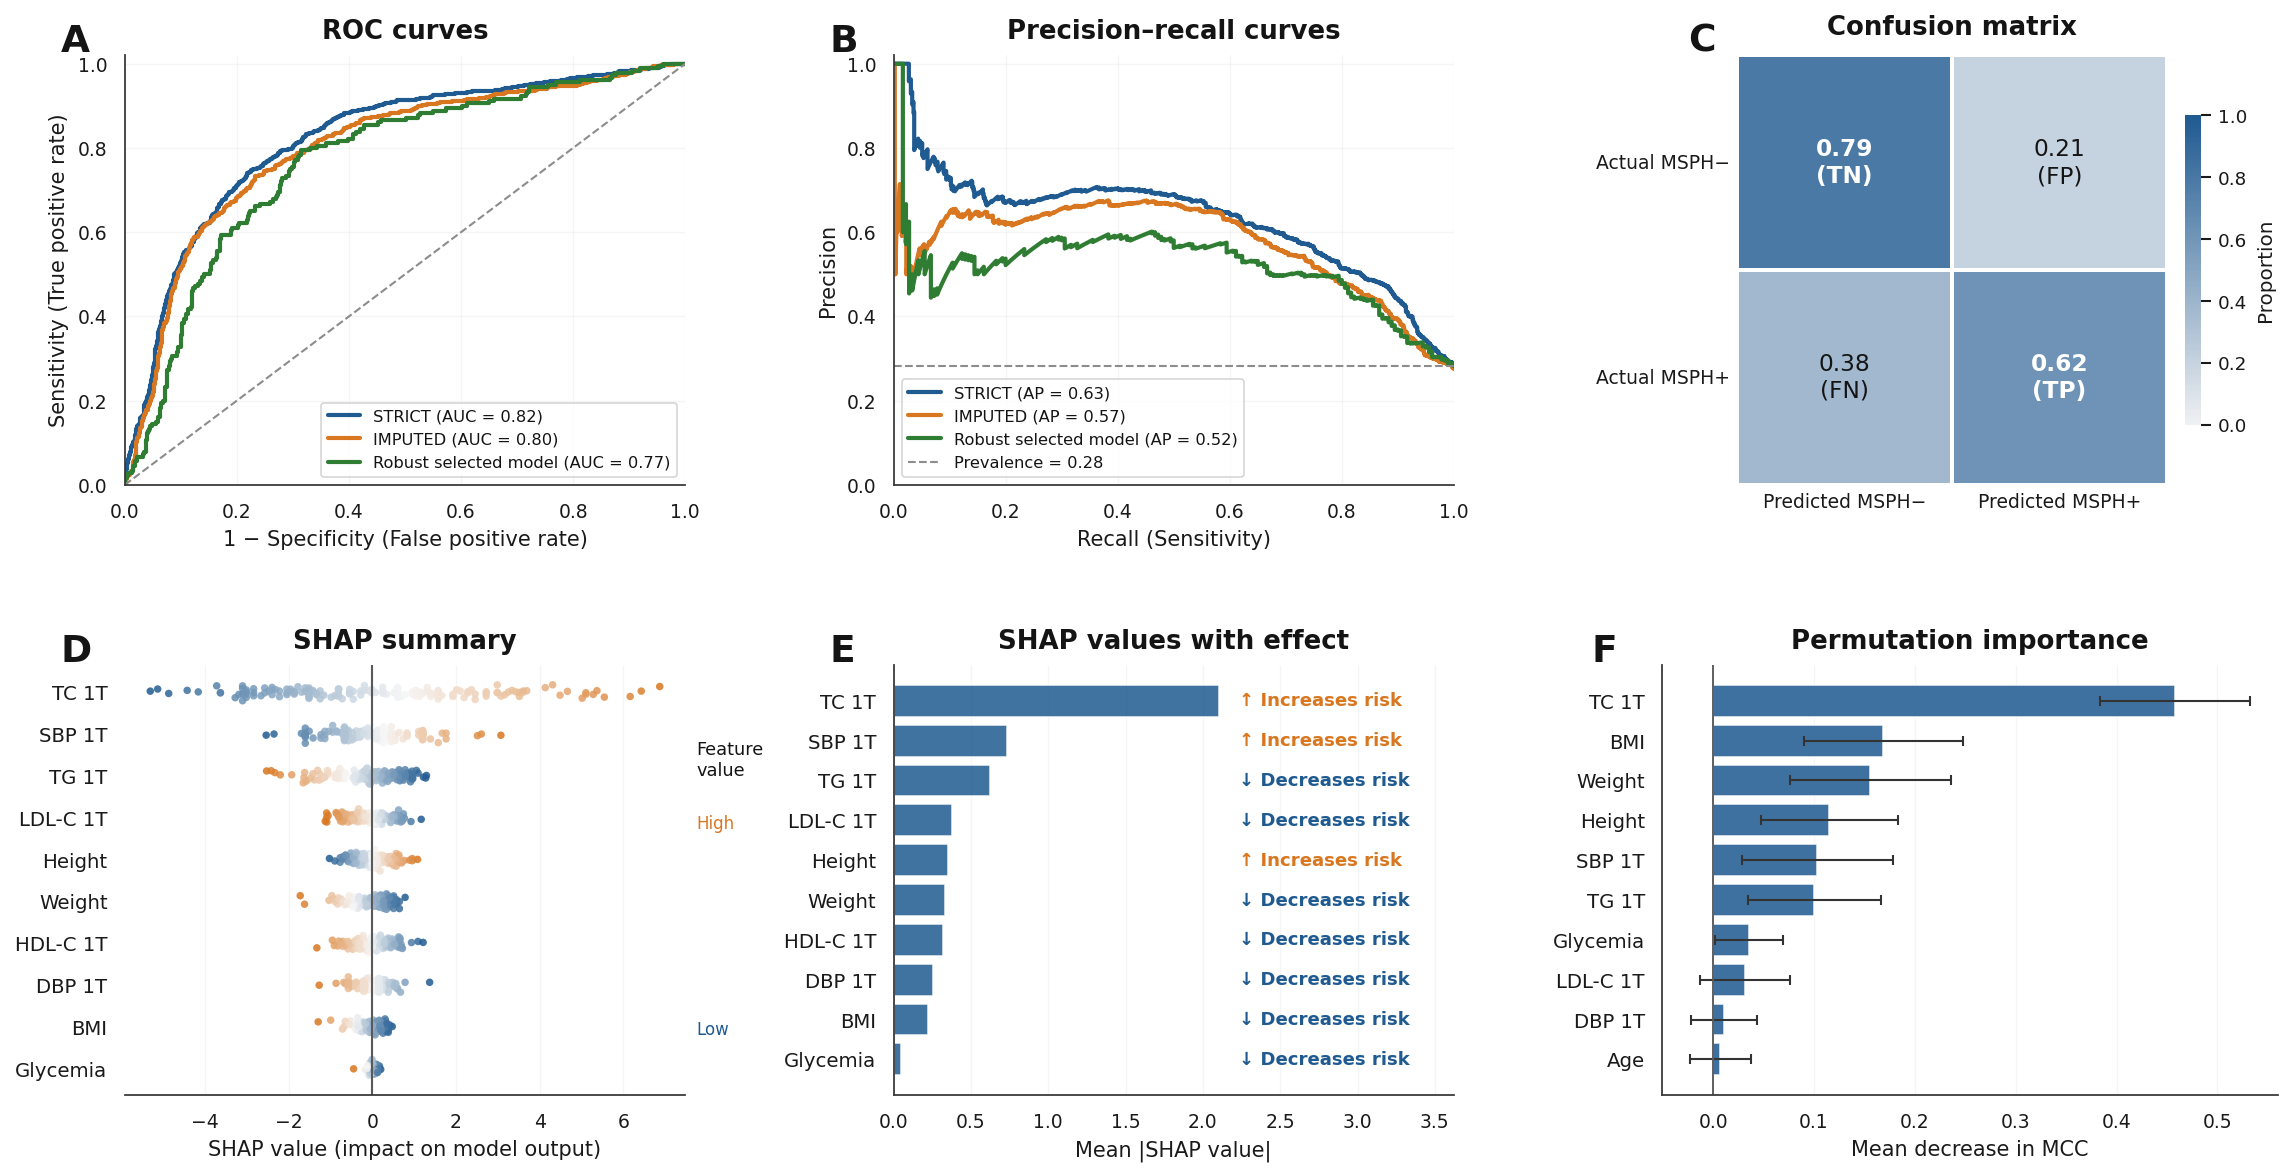

In [16]:

# ---------------------------------------------------------------------
# Generate Figure 3
# ---------------------------------------------------------------------
set_nature_theme()

fig = plt.figure(figsize=(15.6, 8.3), constrained_layout=False)

gs = GridSpec(
    nrows=2,
    ncols=3,
    figure=fig,
    height_ratios=[1.0, 1.0],
    width_ratios=[1.02, 1.02, 1.12],
    hspace=0.42,
    wspace=0.36,
)

axes = {
    "A": fig.add_subplot(gs[0, 0]),
    "B": fig.add_subplot(gs[0, 1]),
    "C": fig.add_subplot(gs[0, 2]),
    "D": fig.add_subplot(gs[1, 0]),
    "E": fig.add_subplot(gs[1, 1]),
    "F": fig.add_subplot(gs[1, 2]),
}

plot_roc(axes["A"])
plot_pr(axes["B"])
plot_confusion(axes["C"])
plot_shap_beeswarm(axes["D"], top_n=10)
plot_shap_effect(axes["E"], top_n=10)
plot_permutation(axes["F"], top_n=10)

for letter, ax in axes.items():
    add_panel_label(ax, letter)

fig.subplots_adjust(left=0.055, right=0.975, top=0.935, bottom=0.10)

png_path = FIG_DIR / f"{FIGURE_BASENAME}.png"
pdf_path = FIG_DIR / f"{FIGURE_BASENAME}.pdf"
svg_path = FIG_DIR / f"{FIGURE_BASENAME}.svg"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

print("Saved:", png_path)
print("Saved:", pdf_path)
print("Saved:", svg_path)

plt.show()


## Caption draft

**Figure 3. Clinical performance and interpretability analysis of the final selected predictive model.**
**A**, Receiver operating characteristic curves for the selected Linear Discriminant Analysis model evaluated under STRICT, IMPUTED, and best overall configuration settings. **B**, Precision–recall curves showing performance under class imbalance across the same evaluation settings. **C**, Normalized confusion matrix for the selected best overall configuration and clinical operating threshold. **D**, SHAP summary plot showing feature-level contributions to model output. **E**, Mean absolute SHAP values with effect direction, highlighting the dominant contribution of first-trimester lipid-related variables. **F**, Cross-validated permutation importance quantified as the mean decrease in MCC after feature perturbation. Together, these analyses indicate that the selected model achieves clinically interpretable discrimination while capturing a biologically coherent lipid-related predictive signature associated with MSPH risk.